In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

# Global sample window size in ms for n averaging measurements
sample_window_size = 1000

group_cols = ["query", "bufferSizeInBytes", "buffersInGlobalBufferManager", "joinStrategy", "numberOfEntriesSliceCaches", "numberOfWorkerThreads", "pageSize"]


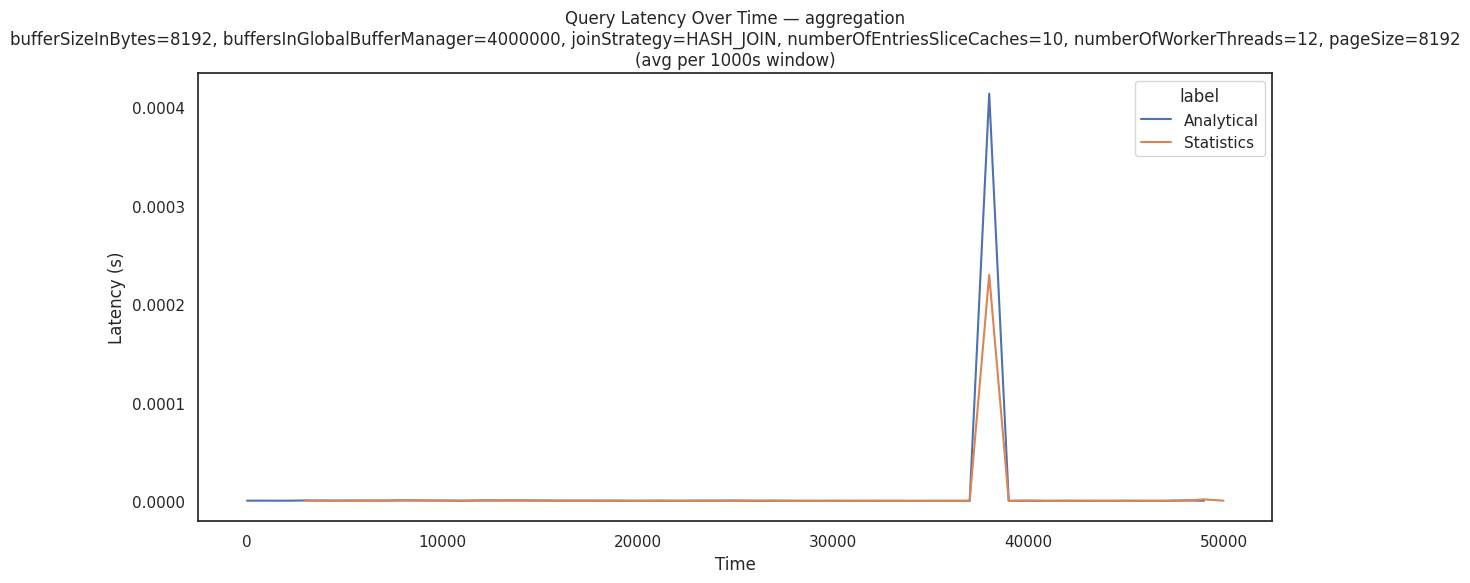

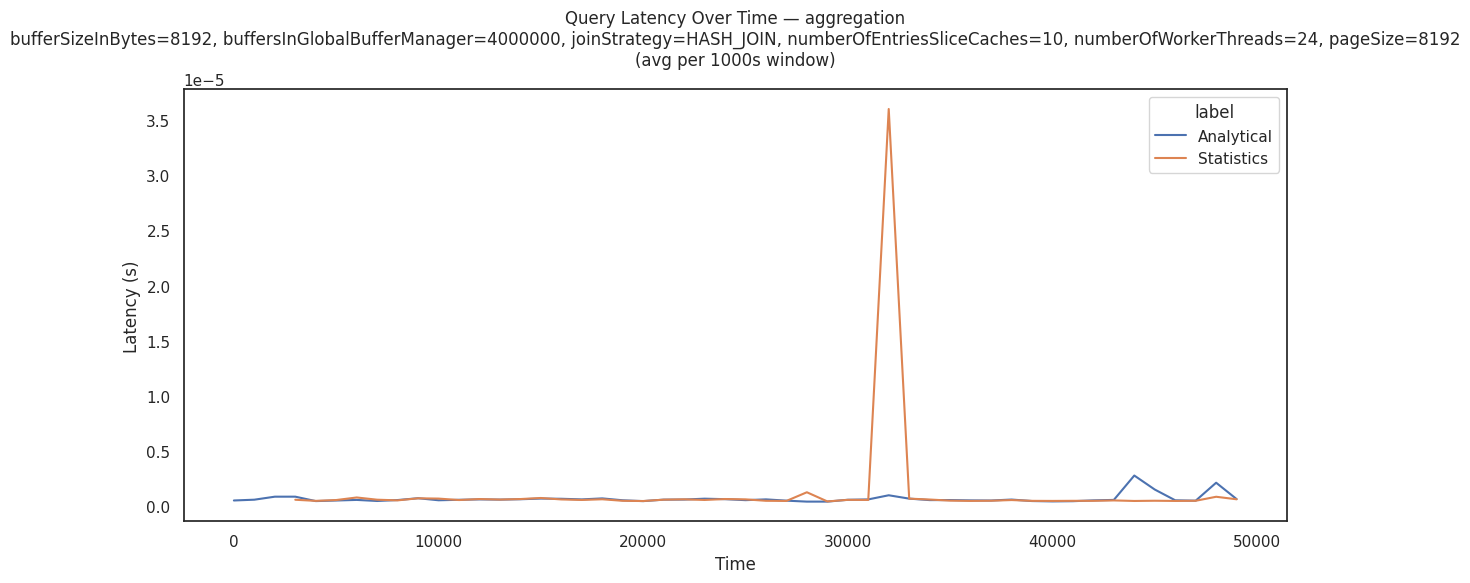

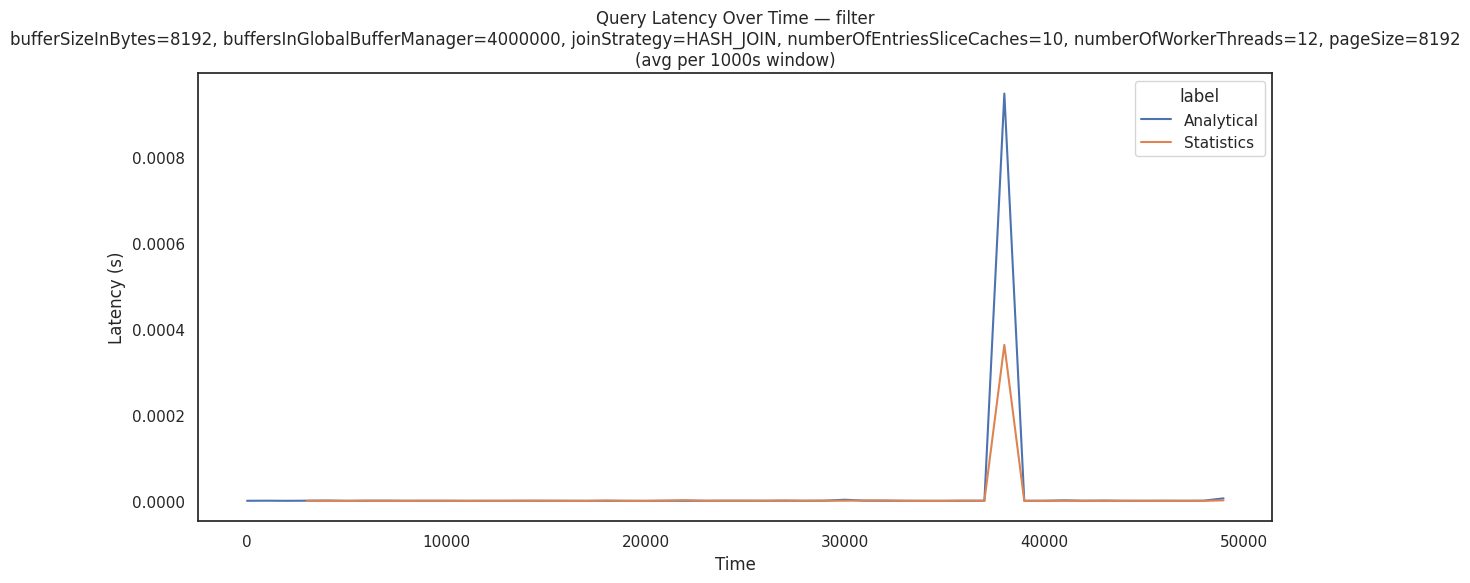

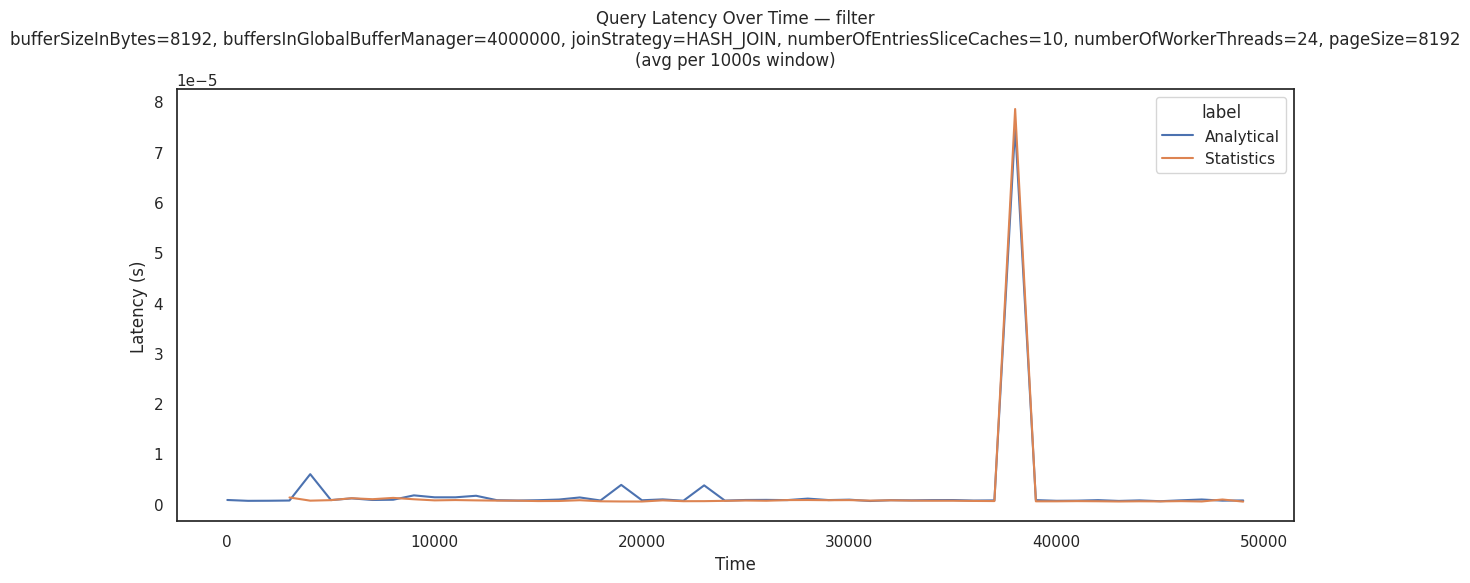

In [34]:
df = pd.read_csv("latency_results_nebulastream_concat.csv")

invalid_modes = df[df["executionMode"] != "COMPILER"]["executionMode"].unique()
assert len(invalid_modes) == 0, f"Found non-COMPILER execution modes in latency data: {invalid_modes}"


for group_key, group_df in df[df["query_type"] == "ANALYTICAL"].groupby(group_cols):
    query_kind = group_key[0]
    config = dict(zip(group_cols[1:], group_key[1:]))
    config_str = ", ".join(f"{k}={v}" for k, v in config.items())

    # Bin analytical data
    analytical_binned = group_df.copy()
    analytical_binned["time_bin"] = (analytical_binned["normalized_start_timestamp"] // sample_window_size) * sample_window_size
    analytical_avg = analytical_binned.groupby("time_bin", as_index=False)["latency"].mean()
    analytical_avg["label"] = "Analytical"

    # Bin statistics queries for the same config
    mask = (df["query_type"] == "STATISTICS") & (df["query"] == query_kind)
    for col, val in config.items():
        mask &= df[col] == val
    statistic_df = df[mask].copy()
    statistic_df["time_bin"] = (statistic_df["normalized_start_timestamp"] // sample_window_size) * sample_window_size
    statistic_avg = statistic_df.groupby("time_bin", as_index=False)["latency"].mean()
    statistic_avg["label"] = "Statistics"

    combined = pd.concat([analytical_avg[["time_bin", "latency", "label"]], statistic_avg[["time_bin", "latency", "label"]]])

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=combined, x="time_bin", y="latency", hue="label")
    plt.xlabel("Time")
    plt.ylabel("Latency (s)")
    plt.title(f"Query Latency Over Time — {query_kind}\n{config_str}\n(avg per {sample_window_size}s window)")
    plt.tight_layout()
    plt.show()

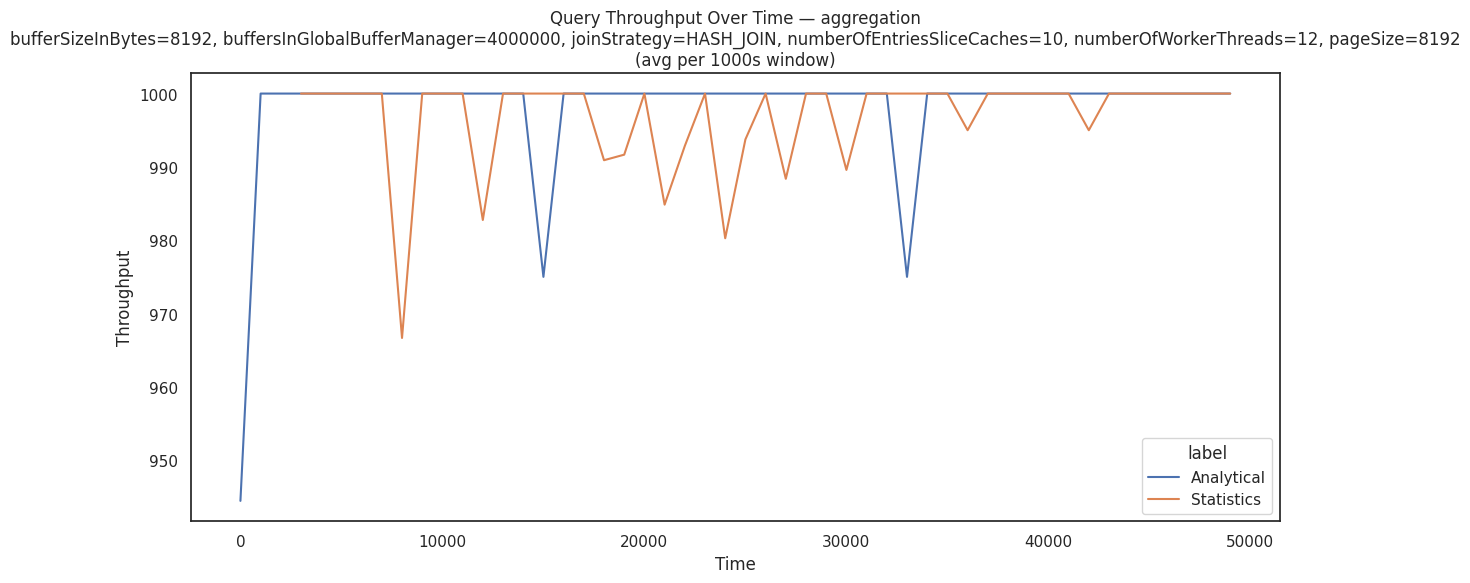

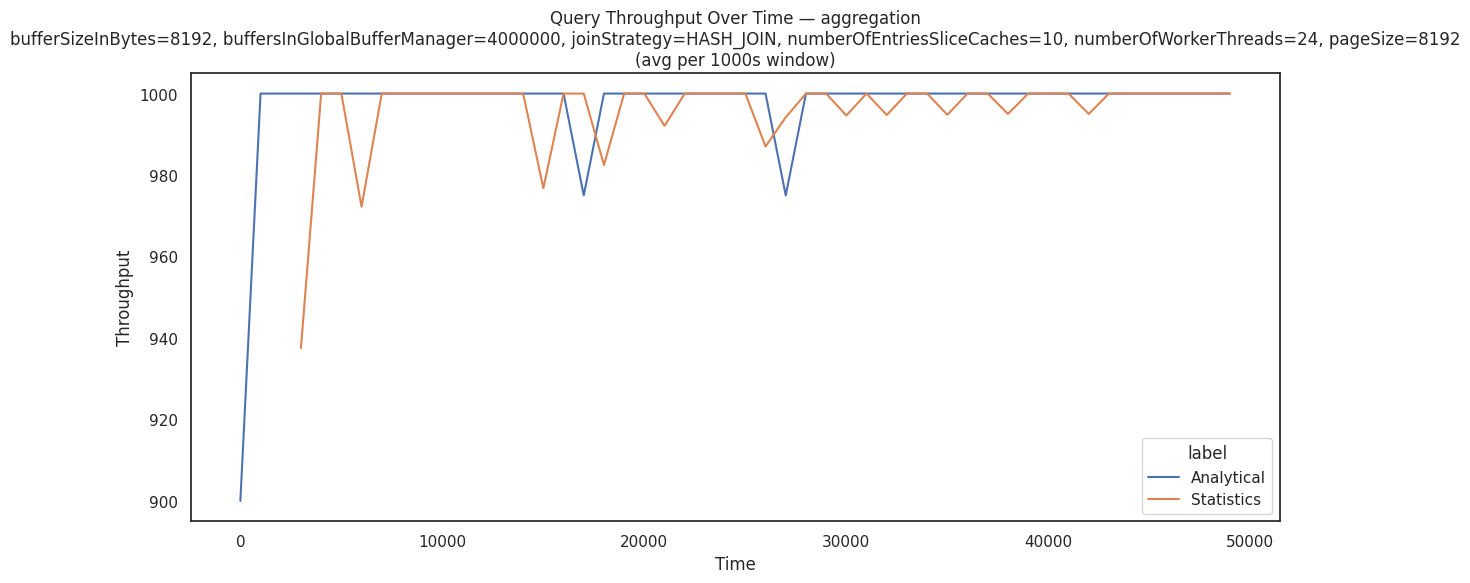

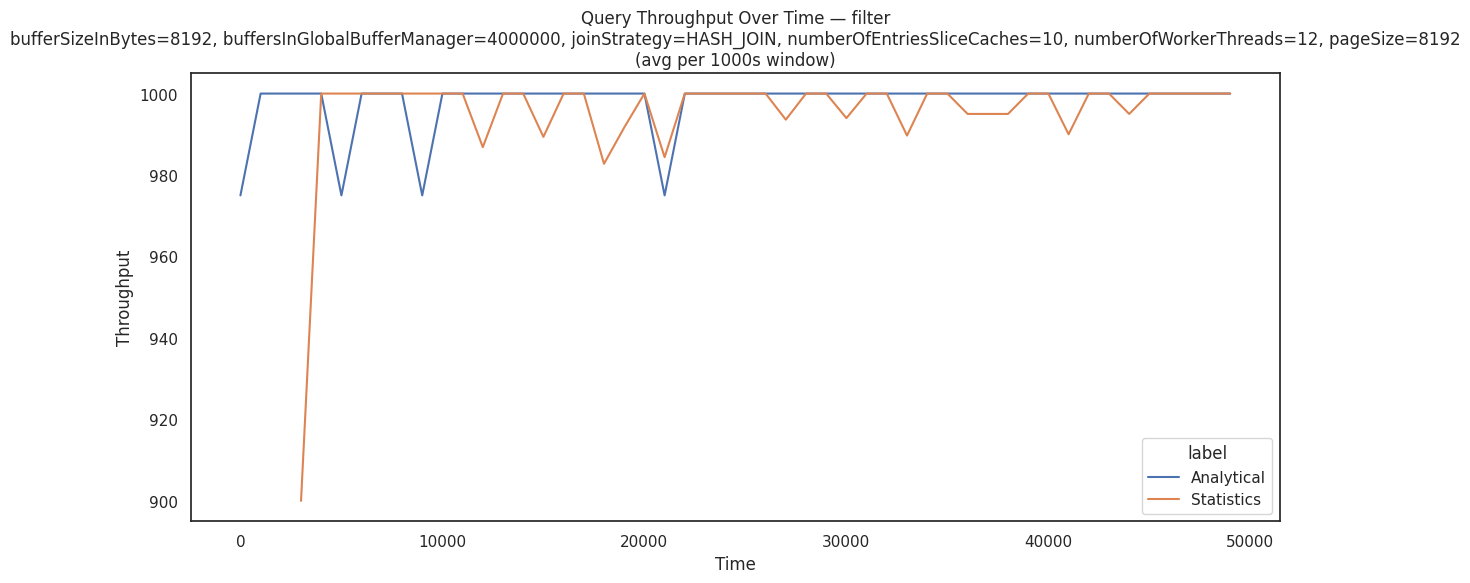

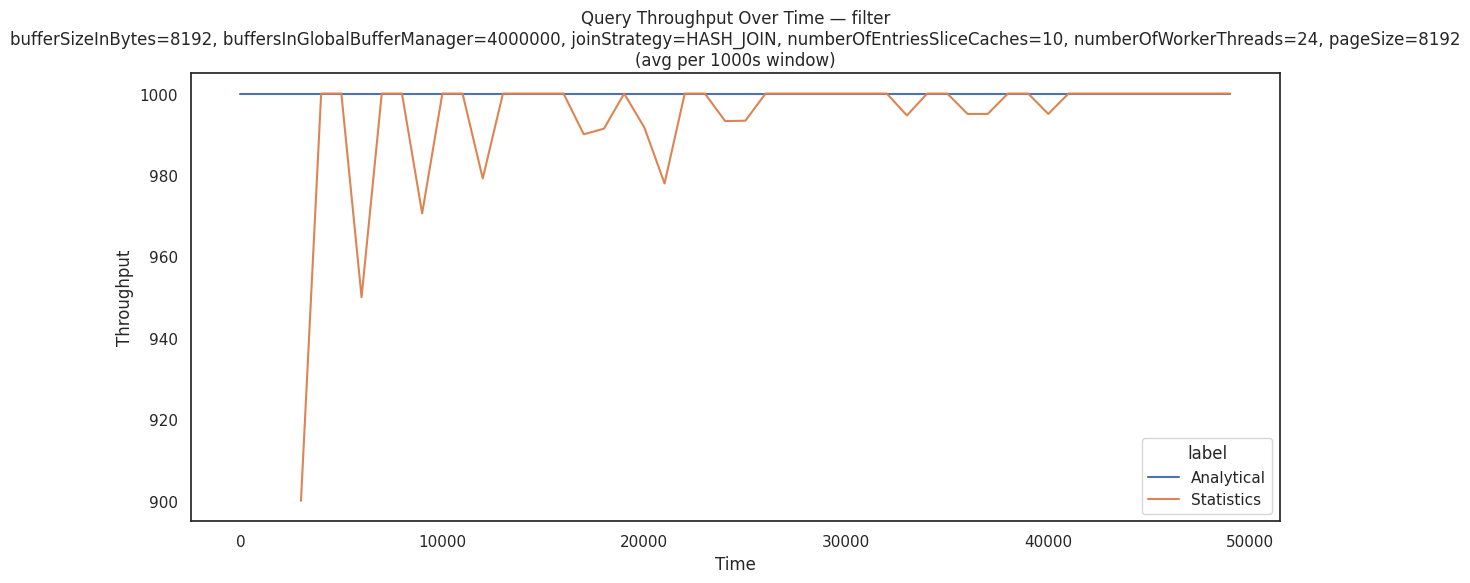

In [35]:
throughput_df = pd.read_csv("throughput_results_nebulastream_concat.csv")

invalid_modes = throughput_df[throughput_df["executionMode"] != "COMPILER"]["executionMode"].unique()
assert len(invalid_modes) == 0, f"Found non-COMPILER execution modes in throughput data: {invalid_modes}"

for group_key, group_df in throughput_df[throughput_df["query_type"] == "ANALYTICAL"].groupby(group_cols):
    query_kind = group_key[0]
    config = dict(zip(group_cols[1:], group_key[1:]))
    config_str = ", ".join(f"{k}={v}" for k, v in config.items())

    # Bin analytical data
    analytical_binned = group_df.copy()
    analytical_binned["time_bin"] = (analytical_binned["normalized_timestamp"] // sample_window_size) * sample_window_size
    analytical_avg = analytical_binned.groupby("time_bin", as_index=False)["throughput"].mean()
    analytical_avg["label"] = "Analytical"

    # Bin statistics queries for the same config
    mask = (throughput_df["query_type"] == "STATISTICS") & (throughput_df["query"] == query_kind)
    for col, val in config.items():
        mask &= throughput_df[col] == val
    statistic_df = throughput_df[mask].copy()
    statistic_df["time_bin"] = (statistic_df["normalized_timestamp"] // sample_window_size) * sample_window_size
    statistic_avg = statistic_df.groupby("time_bin", as_index=False)["throughput"].mean()
    statistic_avg["label"] = "Statistics"

    combined = pd.concat([analytical_avg[["time_bin", "throughput", "label"]], statistic_avg[["time_bin", "throughput", "label"]]])

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=combined, x="time_bin", y="throughput", hue="label")
    plt.xlabel("Time")
    plt.ylabel("Throughput")
    plt.title(f"Query Throughput Over Time — {query_kind}\n{config_str}\n(avg per {sample_window_size}s window)")
    plt.tight_layout()
    plt.show()